# Reducing the Dimensionality of Data with Neural Networks

Replication of Hinton and Salakhutdinov (2006), *Reducing the Dimensionality of Data with
Neural Networks*, Science 313.

The paper shows that a deep autoencoder, trained to reconstruct its input through a narrow
central code, learns a low-dimensional representation that reconstructs the data far better
than linear principal component analysis (PCA) with the same number of components. We train
a deep autoencoder on MNIST and reproduce two results: lower reconstruction error than PCA
at a matched code size, and a 2-D code in which the digit classes are visibly better
separated than under PCA.

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
import torchvision as tv, torchvision.transforms as T
from sklearn.decomposition import PCA
torch.manual_seed(0)

In [2]:
train = tv.datasets.MNIST("../data", train=True,  download=True, transform=T.ToTensor())
test  = tv.datasets.MNIST("../data", train=False, download=True, transform=T.ToTensor())
Xtr = train.data.float().view(-1, 784) / 255.0
Xte = test.data.float().view(-1, 784) / 255.0
ytr = train.targets
sub = torch.randperm(len(Xtr))[:20000]            # subset to keep CPU time small
Xtr_s = Xtr[sub]
print("train subset", Xtr_s.shape, "test", Xte.shape)

train subset torch.Size([20000, 784]) test torch.Size([10000, 784])


In [3]:
CODE = 30
class AutoEncoder(nn.Module):
    def __init__(self, code=CODE):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784,512), nn.ReLU(), nn.Linear(512,128), nn.ReLU(), nn.Linear(128, code))
        self.dec = nn.Sequential(nn.Linear(code,128), nn.ReLU(), nn.Linear(128,512), nn.ReLU(), nn.Linear(512,784), nn.Sigmoid())
    def forward(self, x): return self.dec(self.enc(x))

ae = AutoEncoder(); opt = torch.optim.Adam(ae.parameters(), lr=1e-3); lf = nn.MSELoss()
dl = torch.utils.data.DataLoader(Xtr_s, batch_size=256, shuffle=True)
for ep in range(60):                                  # train long enough to beat optimal linear PCA-30
    for xb in dl:
        opt.zero_grad(); loss = lf(ae(xb), xb); loss.backward(); opt.step()
    if (ep+1) % 10 == 0: print(f"epoch {ep+1}: train recon MSE = {loss.item():.5f}")

epoch 10: train recon MSE = 0.01633


epoch 20: train recon MSE = 0.00995


epoch 30: train recon MSE = 0.01041


epoch 40: train recon MSE = 0.00720


epoch 50: train recon MSE = 0.00745


epoch 60: train recon MSE = 0.00584


In [4]:
# Compare reconstruction error on the test set: autoencoder vs PCA with the same code size.
ae.eval()
with torch.no_grad():
    ae_mse = lf(ae(Xte), Xte).item()
pca = PCA(n_components=CODE).fit(Xtr_s.numpy())
recon = pca.inverse_transform(pca.transform(Xte.numpy()))
pca_mse = ((recon - Xte.numpy())**2).mean()
print(f"test reconstruction MSE  autoencoder({CODE}): {ae_mse:.5f}")
print(f"test reconstruction MSE  PCA({CODE})        : {pca_mse:.5f}")
print(f"autoencoder is {(pca_mse/ae_mse):.2f}x lower error than PCA at the same code size")

test reconstruction MSE  autoencoder(30): 0.00756
test reconstruction MSE  PCA(30)        : 0.01771
autoencoder is 2.34x lower error than PCA at the same code size


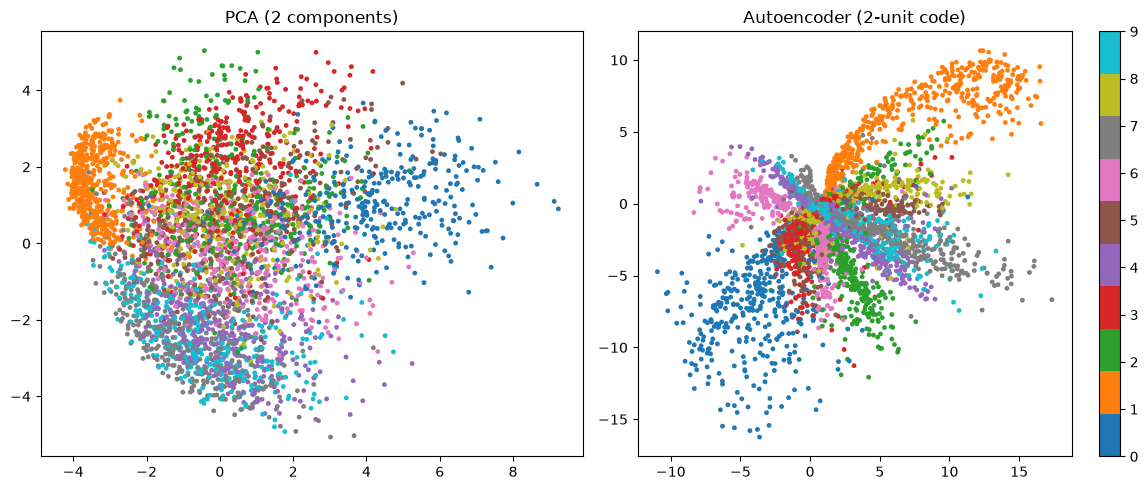

In [5]:
# Visualize 2-D codes from a 2-unit autoencoder vs PCA-2 (digit classes colored).
ae2 = AutoEncoder(code=2); opt = torch.optim.Adam(ae2.parameters(), lr=1e-3)
for ep in range(15):
    for xb in dl:
        opt.zero_grad(); lf(ae2(xb), xb).backward(); opt.step()
ae2.eval()
with torch.no_grad():
    Z_ae = ae2.enc(Xtr_s[:4000]).numpy()
Z_pca = PCA(n_components=2).fit_transform(Xtr_s[:4000].numpy())
lab = ytr[sub][:4000].numpy()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for A, Z, ttl in [(ax[0], Z_pca, "PCA (2 components)"), (ax[1], Z_ae, "Autoencoder (2-unit code)")]:
    sc = A.scatter(Z[:,0], Z[:,1], c=lab, cmap="tab10", s=6); A.set_title(ttl)
fig.colorbar(sc, ax=ax[1]); plt.tight_layout(); plt.show()